---
- filename model_interpretability.ipynb
- author Partha Deka
- revision 1.1
- revision history 1.0 - initial script
- 1.1 - using California Housing dataset from scikit-learn
---


## Using XGBoost's Feature Importance with the California Housing Dataset


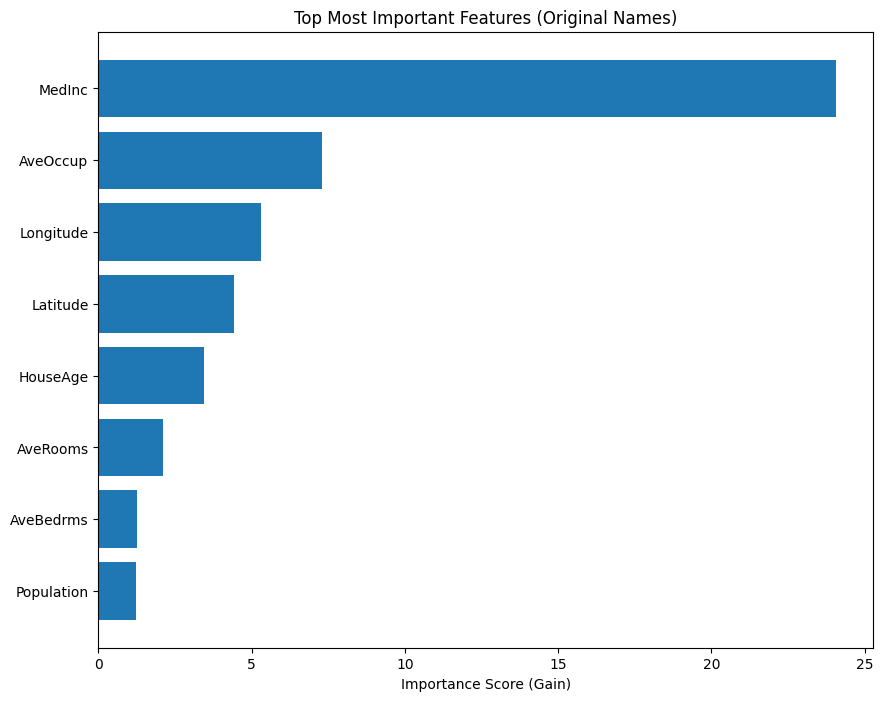

In [1]:
import xgboost as xgb
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Load the California Housing dataset
housingX, housingy = datasets.fetch_california_housing(return_X_y=True, as_frame=True)

# Handle categorical variables by converting them to numeric using pd.get_dummies
housing_data_encoded = pd.get_dummies(housingX)

# Extract original feature names
original_feature_names = housing_data_encoded.columns

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    housing_data_encoded, housingy, test_size=0.2, random_state=42
)

# Standardize the data for optimal performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train an XGBoost model
model = xgb.XGBRegressor(objective="reg:squarederror")
model.fit(X_train_scaled, y_train)

# Retrieve feature importance scores and map them back to original feature names
importance_dict = model.get_booster().get_score(importance_type="gain")

# Create a DataFrame for feature importance
importance_df = pd.DataFrame(
    {
        "Feature": [
            original_feature_names[int(key[1:])] for key in importance_dict.keys()
        ],
        "Importance": importance_dict.values(),
    }
)

# Sort the features by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot the top most important features with original names
plt.figure(figsize=(10, 8))
plt.barh(importance_df["Feature"].head(20), importance_df["Importance"].head(20))
plt.title("Top Most Important Features (Original Names)")
plt.xlabel("Importance Score (Gain)")
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature on top
plt.show()

## Using SHAP with the Housing Dataset


This is a **SHAP waterfall plot**. It is used in machine learning to explain exactly how a model arrived at a specific prediction by showing the contribution of each individual feature.

Think of it as an accounting ledger: you start with a "base budget" and then add or subtract amounts based on different factors until you reach the final "total."

---

### 1. The Starting and Ending Points

* **$E[f(X)] = 1.995$ (The Bottom Right):** This is the **base value** (expected value). It represents what the model would predict on average across your entire dataset. It is your starting point.
* **$f(x) = 0.594$ (The Top Left):** This is the **actual prediction** for this specific data point. The goal of this chart is to show how we got from $1.995$ down to $0.594$.

### 2. The Features (Left Axis)

The left side shows the **feature names** and their **actual values** for this specific observation.

* For example, `Latitude = 0.195` and `MedInc = -1.155`. These values are usually scaled or normalized, which is why they might look different from raw data (like dollars or degrees).

### 3. The Arrows (Contributions)

The "waterfall" is composed of blue and red arrows that push the prediction away from the base value.

* **Blue Arrows (Negative SHAP):** These features **decreased** the prediction.
* *Example:* The fact that `Latitude` is $0.195$ dropped the prediction by **$-0.6$**.


* **Red Arrows (Positive SHAP):** These features **increased** the prediction.
* *Example:* The `AveBedrms` value of $-0.172$ increased the prediction slightly by **$+0.02$**.



### 4. Interpretation Summary

For this specific house (or data point):

1. The model starts with an average prediction of **$1.995$**.
2. Significant factors like **Latitude** ($-0.6$) and **MedInc** ($-0.35$) dragged the value down heavily.
3. Minor factors like **HouseAge** and **AveBedrms** nudged it up just a tiny bit.
4. The final result is a prediction of **$0.594$**.

---

### Quick Check

If you sum up all the numbers on the arrows and add them to the base value, they will equal the final prediction:


$$1.995 - 0.6 - 0.35 - 0.18 - 0.18 - 0.09 - 0.02 + 0.02 + 0.01 = 0.594$$

Would you like me to help you interpret what these specific features (like `MedInc` or `AveOccup`) might represent in the context of the dataset being used?

 99%|===================| 4088/4128 [00:25<00:00]        

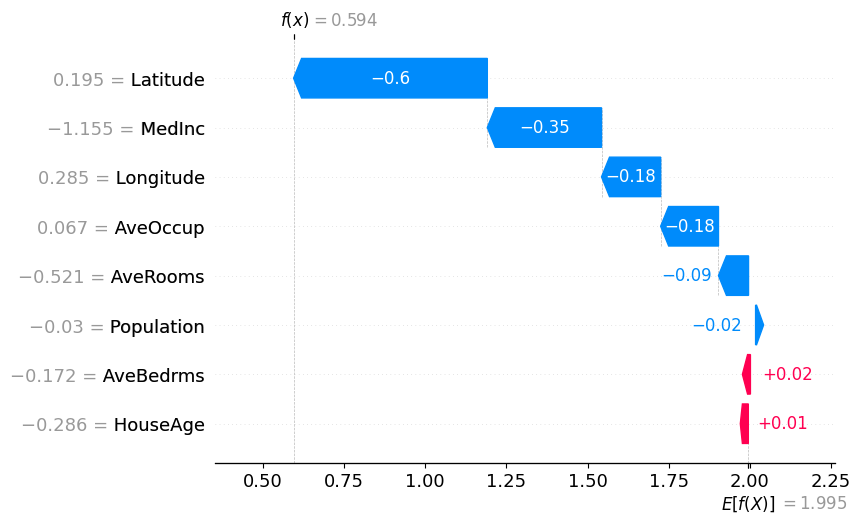

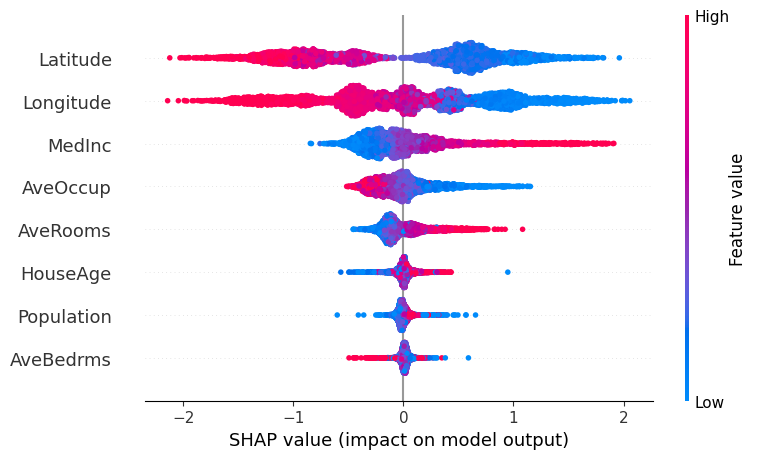

In [2]:
import shap
import pandas as pd

# Create a DataFrame for the scaled X_test with proper feature names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Initialize SHAP explainer using the model and the scaled training data
explainer = shap.Explainer(model, X_train_scaled, feature_names=X_train.columns)

# Compute SHAP values for the test set
shap_values = explainer(X_test_scaled)

# SHAP Waterfall plot for a single prediction (now no need for feature_names parameter)
shap.waterfall_plot(shap_values[0])

# SHAP Summary plot for global feature importance (uses the DataFrame to preserve feature names)
shap.summary_plot(shap_values, X_test_scaled_df)

## Using LIME to Interpret XGBoost Predictions


In [ ]:
import lime
import lime.lime_tabular


# Define a wrapper for model.predict to ensure it uses scaled data
def predict_fn(x):
    x_scaled = scaler.transform(x)  # Scale the data before predicting
    return model.predict(x_scaled).flatten()  # Ensure the output is 1D for LIME


# Initialize LIME explainer using the unscaled training data
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,  # Use unscaled data
    feature_names=X_train.columns,
    mode="regression",
    discretize_continuous=False,  # Disable discretization for continuous features
)

# Explain a single instance (e.g., the first test instance)
i = 0
exp = explainer.explain_instance(X_test.values[i], predict_fn, num_features=5)

# Show the explanation
exp.show_in_notebook(show_table=True)

## Using ELI5 to Explain XGBoost Models


In [3]:
import eli5
from eli5.sklearn import PermutationImportance

# Fit the permutation importance model
perm = PermutationImportance(model, random_state=42).fit(X_test_scaled, y_test)

# Display feature importance using ELI5
eli5.show_weights(perm, feature_names=X_test.columns.tolist())

Weight,Feature
1.4170 ± 0.0543,Latitude
1.2683 ± 0.0484,Longitude
0.3664 ± 0.0156,MedInc
0.1504 ± 0.0136,AveOccup
0.1034 ± 0.0074,AveRooms
0.0502 ± 0.0082,HouseAge
0.0083 ± 0.0011,AveBedrms
0.0055 ± 0.0030,Population


## `PDP` implementatipon on the Housing dataset using scikit-learn's `PartialDependenceDisplay`


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.inspection import plot_partial_dependence
import matplotlib.pyplot as plt
import pandas as pd

# Load the housing dataset
housingX, housingy = datasets.fetch_california_housing(return_X_y=True, as_frame=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    housingX, housingy, test_size=0.2, random_state=42
)

# Train the Gradient Boosting model
gbr = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
gbr.fit(X_train, y_train)

# Get feature importances from the Gradient Boosting model
importances = gbr.feature_importances_

# Create a DataFrame to pair feature names with their importance scores
feature_importances_df = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": importances}
)

# Sort the features by importance and select the top 6
top_features = feature_importances_df.sort_values(
    by="Importance", ascending=False
).head(6)
print("Top 6 Important Features:")
print(top_features)

Top 6 Important Features:
     Feature  Importance
0     MedInc    0.578121
5   AveOccup    0.132026
7  Longitude    0.105324
6   Latitude    0.096638
1   HouseAge    0.043179
2   AveRooms    0.025655


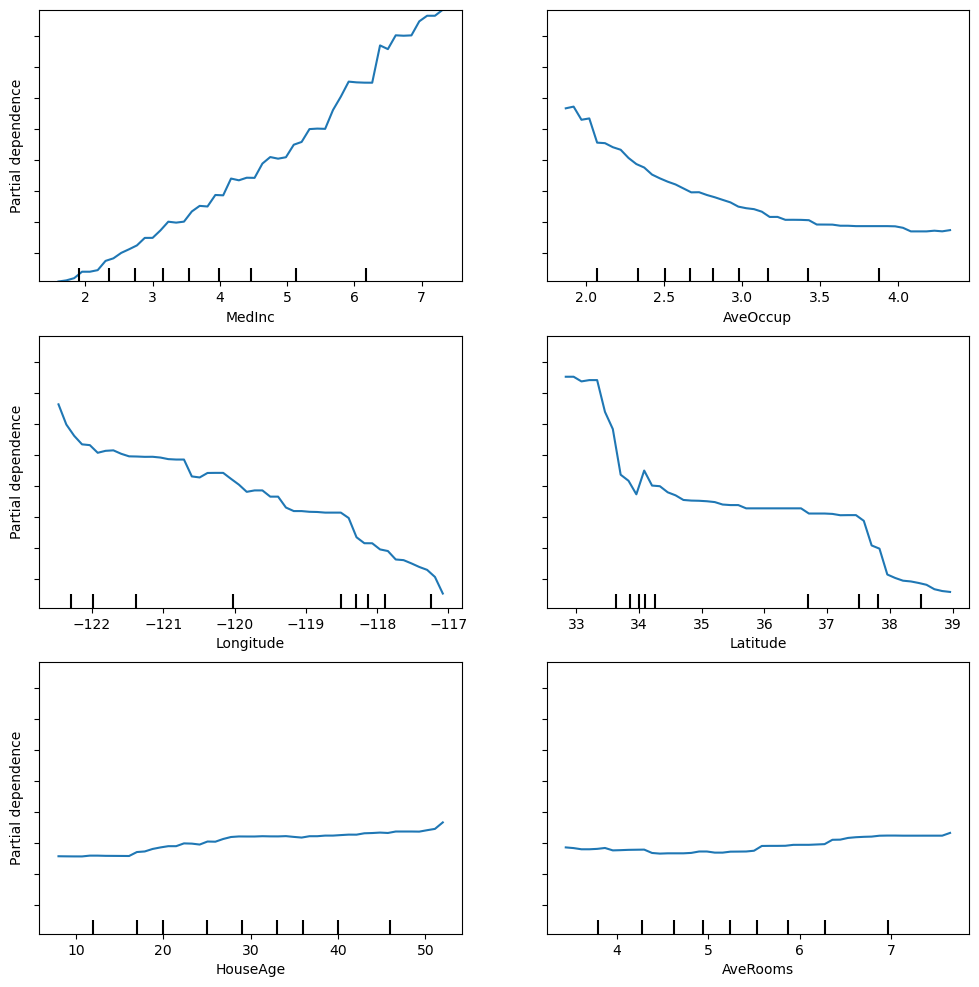

In [ ]:
# Get the indices of the top 6 features
top_features_indices = [
    X_train.columns.get_loc(feature) for feature in top_features["Feature"]
]

# Generate PDP plots for the top 6 features
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(12, 12), sharey=True)
plot_partial_dependence(
    gbr,
    X_train,
    top_features_indices,
    feature_names=X_train.columns,
    grid_resolution=50,
    ax=ax,
)

# Show the plots
plt.show()